# Person 1: Probabilistic and Linear NLP Baselines
CS3244 Group 1 — For Real? Identifying Markers of Sarcasm through Explainable ML  
Contributor: SHI Yuke

This is the primary notebook deliverable. It contains the complete model,
training, evaluation, explanation, plotting and artifact-export code directly
in executable cells. No separate Person 1 Python scripts are required or
included. It uses the team's existing `pipeline/load.py` and shared cleaned
datasets inside the group repository.

**Research question:** How much can full sparse lexical evidence explain, and
what changes when interpretable reply-surface features are added?

Part A defines the complete experiment. Part B executes it or reviews the saved
completed run. `RUN_TRAINING=False` preserves the completed results; set it to
`True` to reproduce all fits. `RUN_OOF` separately controls the optional Person 6
stacking handoff. The displayed scores come from the completed full-data run.

**Repository destination:** `python_nb_ver2`.

**Submission scope:** Fitted model files under `artifacts/person1/` are intentionally excluded from GitHub and retained locally. Metrics, figures and ensemble prediction tables are included. The optional saved-model demonstration skips when artifacts are absent; rerun training and export to regenerate them.


## Part A — Complete experiment implementation
### A1. Repository and execution mode

In [1]:
from pathlib import Path
import sys, json
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().resolve()
while not (ROOT / 'pipeline' / 'load.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'pipeline' / 'load.py').exists(), 'Open this notebook inside the repository.'
RUN_TRAINING = False
RUN_OOF = False
print('Repository:', ROOT)
print('Mode:', 'retrain' if RUN_TRAINING else 'review saved completed run')

Repository: /workspace/scratch/ded6a552416d/cs3244_group1
Mode: review saved completed run


### A2. Libraries and fixed experimental settings
Seeds, feature allow-lists, split sizes and search grids are declared before fitting.

In [2]:
"""Person 1: full sparse TF-IDF NB/LR baselines, reproducible from the notebook.

Only the shared, already-cleaned split files are accepted. No test data are
used for vocabulary, scaling, model selection, or threshold selection.
"""
from __future__ import annotations

import gc
import hashlib
import importlib.metadata
import json
import platform
import sys
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

sys.path.insert(0, str(ROOT / "pipeline"))
from load import load_split, MODEL_SAFE_FEATURES, EXCLUDED_FEATURES  # noqa: E402

SEED = 3244
RESULTS = ROOT / "results" / "person1"
MODELS = ROOT / "models" / "person1"
FIGURES = ROOT / "figures" / "person1"
CACHE = ROOT / ".cache" / "person1"
TARGET_PRECISION = 0.75  # matches the existing glass-box config
TARGETS = ["figlang_reddit", "figlang_twitter", "tweeteval_irony", "news_headlines"]
EXPECTED = {
    "sarc_random": (639638, 137066, 137065),
    "sarc_temporal": (484447, 182441, 242091),
    "sarc_subreddit": (639838, 135123, 135534),
    "figlang_reddit": (3729, 659, 1756),
    "figlang_twitter": (4028, 711, 1715),
    "tweeteval_irony": (2853, 950, 780),
    "news_headlines": (19862, 4256, 4257),
}
SURFACE = [c for c in MODEL_SAFE_FEATURES
           if not c.startswith("parent_") and c != "len_ratio_to_parent"]
assert not (set(SURFACE) & set(EXCLUDED_FEATURES))
# Fixed bins chosen from the supplied EDA, not from validation/test labels.
WORD_EDGES = np.array([3, 6, 8, 12, 20, 40])
WORD_NAMES = ["words_0_3", "words_4_6", "words_7_8", "words_9_12",
              "words_13_20", "words_21_40", "words_41_plus"]
GRIDS = {
    "MNB": [{"alpha": x} for x in (0.1, 1.0, 10.0)],
    "CNB": [{"alpha": x} for x in (0.1, 1.0, 10.0)],
    "LR": [{"C": x, "penalty": "l2"} for x in (0.1, 1.0, 10.0)]
          + [{"C": 1.0, "penalty": "l1"}],
}



### A3. Shared data loading and leakage checks
Load the frozen team splits and check row identity and parent-group separation.

In [3]:
def setup():
    for d in (RESULTS, MODELS, FIGURES, CACHE, RESULTS / "predictions"):
        d.mkdir(parents=True, exist_ok=True)
    versions = {p: importlib.metadata.version(p) for p in
                ("numpy", "pandas", "scipy", "scikit-learn", "joblib", "pyarrow")}
    versions["python"] = platform.python_version()
    write_json(RESULTS / "environment.json", versions)
    return versions


def write_json(path, obj):
    Path(path).write_text(json.dumps(obj, indent=2, ensure_ascii=False,
                                   allow_nan=False, default=str) + "\n", encoding="utf-8")


def text_of(df):
    col = "comment_clean" if "comment_clean" in df else "text_clean"
    return df[col].fillna("").astype(str)


def row_ids(df):
    """Content-derived IDs: independent of row order and of the target label."""
    return text_of(df).map(lambda s: hashlib.blake2b(s.encode("utf-8"), digest_size=16).hexdigest())


def load_frame(dataset, partition):
    primary = dataset.startswith("sarc_")
    cols = ["comment_clean" if primary else "text_clean", "label"] + SURFACE
    if primary:
        cols += ["parent_key"]
    df = load_split(dataset, partition, columns=cols).reset_index(drop=True)
    expected = EXPECTED[dataset][("train", "val", "test").index(partition)]
    if len(df) != expected:
        raise ValueError(f"{dataset}/{partition}: {len(df)} rows, expected {expected}. "
                         "Resolve data-version mismatch before comparing with teammates.")
    if not df.label.isin([0, 1]).all() or df.label.nunique() != 2:
        raise ValueError("Both binary labels must be present")
    return df


def audit_data():
    """Audit counts, exact row identities, and parent groups without training."""
    rows = []
    for dataset in EXPECTED:
        ids, groups = {}, {}
        for partition in ("train", "val", "test"):
            df = load_frame(dataset, partition)
            rid = row_ids(df)
            if not rid.is_unique:
                raise ValueError(f"Duplicate text identities: {dataset}/{partition}")
            ids[partition] = set(rid)
            if "parent_key" in df:
                groups[partition] = set(df.parent_key)
            rows.append({"dataset": dataset, "split": partition, "rows": len(df),
                         "positive_rate": float(df.label.mean()),
                         "ordered_row_id_sha256": hashlib.sha256("\n".join(rid).encode()).hexdigest()})
            del df
        for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
            assert not ids[a] & ids[b], f"Text overlap: {dataset} {a}/{b}"
            if groups:
                assert not groups[a] & groups[b], f"Parent overlap: {dataset} {a}/{b}"
    out = pd.DataFrame(rows)
    out.to_csv(RESULTS / "data_audit.csv", index=False)
    return out

### A4. Reply surface features
Fit scaling only on the training partition. Fixed word-count bins and nonnegative values support all three models.

In [4]:
class SurfaceTransformer(TransformerMixin, BaseEstimator):
    """Reply-only nonnegative features; no parent, community, author or audit data.

    Counts are log1p-transformed and scaled using training standard deviations
    without centering. Word count becomes seven pre-specified indicator bins.
    Nonnegative output supports both NB variants as well as LR.
    """
    def _raw(self, df):
        missing = set(SURFACE) - set(df)
        if missing:
            raise ValueError(f"Missing required surface columns: {sorted(missing)}")
        cols = [c for c in SURFACE if c != "n_words"]
        a = df[cols].to_numpy(dtype=np.float64)
        if not np.isfinite(a).all() or (a < 0).any():
            raise ValueError("Surface features must be finite and nonnegative")
        for j, name in enumerate(cols):
            if name.startswith("n_"):
                a[:, j] = np.log1p(a[:, j])
        words = df.n_words.to_numpy(dtype=float)
        if not np.isfinite(words).all() or (words < 0).any():
            raise ValueError("Invalid word counts")
        bins = np.eye(7)[np.searchsorted(WORD_EDGES, words, side="left")]
        return np.column_stack([a, bins])

    def fit(self, X, y=None):
        self.scaler_ = StandardScaler(with_mean=False).fit(self._raw(X))
        return self

    def transform(self, X):
        return sparse.csr_matrix(self.scaler_.transform(self._raw(X)))

    def get_feature_names_out(self, input_features=None):
        return np.array(["surface:" + c for c in SURFACE if c != "n_words"]
                        + ["surface:" + c for c in WORD_NAMES], dtype=object)

The saved models identify this transformer as `experiment.SurfaceTransformer`.
The small compatibility registration below points that name to the class just
defined in this notebook. It does not read or execute `experiment.py`.

In [5]:
import types
_model_compatibility = types.ModuleType('experiment')
SurfaceTransformer.__module__ = 'experiment'
_model_compatibility.SurfaceTransformer = SurfaceTransformer
sys.modules['experiment'] = _model_compatibility

### A5. Sparse TF-IDF and classifiers
Full word TF-IDF is used without SVD. MNB, CNB and LR are created with explicit settings; convergence is checked.

In [6]:
def make_vectorizer(ngram_max):
    # Matches Person 2's current TF-IDF settings for the bigram experiment.
    # No SVD, stopword removal or max_features truncation.
    return TfidfVectorizer(ngram_range=(1, ngram_max), min_df=3,
                           sublinear_tf=True, dtype=np.float64)


def make_model(family, params):
    if family == "MNB":
        return MultinomialNB(**params)
    if family == "CNB":
        return ComplementNB(norm=False, **params)
    return LogisticRegression(solver="liblinear", max_iter=1000, tol=1e-4,
                              random_state=SEED, **params)


def fit_checked(model, X, y):
    t = time.perf_counter()
    with warnings.catch_warnings(record=True) as seen, threadpool_limits(limits=2):
        warnings.simplefilter("always", ConvergenceWarning)
        model.fit(X, y)
    if any(issubclass(w.category, ConvergenceWarning) for w in seen):
        raise RuntimeError("Model did not converge; do not publish its scores as a completed fit")
    return time.perf_counter() - t


def build_features(train, val, ngram_max):
    t = time.perf_counter()
    vec = make_vectorizer(ngram_max)
    xt = vec.fit_transform(text_of(train))
    fit_seconds = time.perf_counter() - t
    xv = vec.transform(text_of(val))
    return vec, xt, xv, fit_seconds

### A6. Metrics and validation-only threshold selection
ROC-AUC and average precision measure ranking. The operating threshold maximizes validation recall subject to precision ≥ 0.75.

In [7]:
def select_threshold(y, p, target=TARGET_PRECISION):
    """Maximize validation recall subject to precision >= target.

    Exclude the PR-curve sentinel (no positive predictions); unavailable targets
    are represented by None rather than by inventing an operating point.
    """
    precision, recall, thresholds = precision_recall_curve(y, p)
    good = np.flatnonzero(precision[:-1] >= target)
    if not len(good):
        return None
    best = good[np.argmax(recall[good])]
    return float(thresholds[best])


def scores(y, p, threshold):
    pred = p >= threshold
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"roc_auc": float(roc_auc_score(y, p)),
            "pr_auc": float(average_precision_score(y, p)),
            "pr_auc_definition": "average_precision",
            "accuracy": float(accuracy_score(y, pred)),
            "precision": float(precision_score(y, pred, zero_division=0)),
            "recall": float(recall_score(y, pred, zero_division=0)),
            "f1": float(f1_score(y, pred, zero_division=0)),
            "brier_score": float(brier_score_loss(y, p)),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

### A7. Hyperparameter search
Fit all 20 candidates on the full random training split; select by its separate validation ROC-AUC.

In [8]:
def tune():
    """20 full-training-set text-only fits; select separately for each family."""
    train, val = (load_frame("sarc_random", p) for p in ("train", "val"))
    trials, selected = [], {}
    for ng in (1, 2):
        vec, xt, xv, vector_seconds = build_features(train, val, ng)
        joblib.dump(vec, CACHE / f"vectorizer_{ng}.joblib", compress=3)
        print(f"TF-IDF (1,{ng}): {xt.shape}, {vector_seconds:.1f}s", flush=True)
        for family, grid in GRIDS.items():
            for params in grid:
                model = make_model(family, params)
                seconds = fit_checked(model, xt, train.label)
                p = model.predict_proba(xv)[:, 1]
                auc = float(roc_auc_score(val.label, p))
                trial = {"model": family, "ngram_max": ng, **params,
                         "val_roc_auc": auc, "val_average_precision": float(average_precision_score(val.label,p)),
                         "fit_seconds": seconds, "vectorizer_fit_seconds": vector_seconds,
                         "train_rows": len(train), "val_rows": len(val),
                         "n_features": xt.shape[1], "seed": SEED, "converged": True}
                trials.append(trial)
                if family not in selected or auc > selected[family]["val_roc_auc"]:
                    selected[family] = {"params": params, "ngram_max": ng, "val_roc_auc": auc}
                print(f"  {family} {params}: val AUC {auc:.6f}, {seconds:.1f}s", flush=True)
                pd.DataFrame(trials).to_csv(RESULTS / "tuning_trials.csv", index=False)
        del vec, xt, xv
        gc.collect()
    write_json(RESULTS / "selected.json", selected)
    return pd.DataFrame(trials), selected

### A8. Prediction, saved models and evaluation
Save probabilities with stable row IDs and verify estimator save/reload consistency.

In [9]:
def matrix(bundle, df):
    x = bundle["vectorizer"].transform(text_of(df))
    if bundle.get("surface") is not None:
        x = sparse.hstack([x, bundle["surface"].transform(df)], format="csr")
    return x


def predict(bundle, df):
    return bundle["model"].predict_proba(matrix(bundle, df))[:, 1]


def save_bundle(path, bundle, validation):
    """Verify that a saved/reloaded estimator produces the same probabilities."""
    before = predict(bundle, validation.iloc[:64])
    joblib.dump(bundle, path, compress=3)
    after = predict(joblib.load(path), validation.iloc[:64])
    np.testing.assert_allclose(before, after, rtol=1e-12, atol=1e-12)


def evaluate(bundle, df, dataset, partition, model_id, fit_seconds=0.0):
    t = time.perf_counter()
    p = predict(bundle, df)
    infer_seconds = time.perf_counter() - t
    output = pd.DataFrame({"row_id": row_ids(df), "row_position": np.arange(len(df)),
                           "label": df.label.to_numpy(), "probability": p})
    output.to_parquet(RESULTS / "predictions" / f"{model_id}__{dataset}__{partition}.parquet", index=False)
    rows = []
    thresholds = {"default_0.50": 0.5}
    if bundle["threshold"] is not None:
        thresholds["source_validation_precision_0.75"] = bundle["threshold"]
    for policy, threshold in thresholds.items():
        rows.append({"dataset": dataset, "split": partition, "model": bundle["family"],
                     "model_id": model_id, "training_dataset": bundle["training_dataset"],
                     "representation": bundle["representation"], "ngram_max": bundle["ngram_max"],
                     "seed": SEED, "threshold": threshold, "threshold_policy": policy,
                     "threshold_source": "fixed" if policy == "default_0.50" else "sarc_random/val", "rows": len(df),
                     "train_rows": bundle["train_rows"], "n_features": bundle["model"].n_features_in_,
                     "fit_seconds": fit_seconds, "inference_seconds": infer_seconds,
                     **scores(df.label, p, threshold)})
    return rows

### A9. Final fitting and stress/transfer experiments
Each stress split gets its own fitted vectorizer, scaler and model. Supplementary tests use frozen source-trained LR models.

In [10]:
def fit_and_evaluate(selected):
    """Refit chosen text configurations; surface ablation freezes their settings.

    Refit independently on all three schemes. Keep validation separate (do not
    refit on train+val). Source-selected thresholds are frozen for stress and
    transfer, so no stress/target-domain threshold tuning takes place.
    """
    all_metrics, thresholds, fit_log = [], {}, []
    for dataset in ("sarc_random", "sarc_temporal", "sarc_subreddit"):
        train, val = (load_frame(dataset, p) for p in ("train", "val"))
        surface = SurfaceTransformer().fit(train)
        st, sv = surface.transform(train), surface.transform(val)
        for ng in sorted({x["ngram_max"] for x in selected.values()}):
            vec, xt, xv, vec_seconds = build_features(train, val, ng)
            xs_train = sparse.hstack([xt, st], format="csr")
            xs_val = sparse.hstack([xv, sv], format="csr")
            for family, choice in selected.items():
                if choice["ngram_max"] != ng:
                    continue
                for use_surface in (False, True):
                    representation = "reply_tfidf_surface" if use_surface else "reply_tfidf"
                    key = f"{family.lower()}_{representation}"
                    model_id = f"{dataset}__{key}"
                    xtrain, xval = (xs_train, xs_val) if use_surface else (xt, xv)
                    model = make_model(family, choice["params"])
                    seconds = fit_checked(model, xtrain, train.label)
                    vp = model.predict_proba(xval)[:, 1]
                    if dataset == "sarc_random":
                        thresholds[key] = select_threshold(val.label, vp)
                    bundle = {"model": model, "vectorizer": vec,
                              "surface": surface if use_surface else None,
                              "family": family, "representation": representation,
                              "ngram_max": ng, "params": choice["params"],
                              "threshold": thresholds[key], "training_dataset": dataset,
                              "train_rows": len(train), "seed": SEED}
                    save_bundle(MODELS / f"{model_id}.joblib", bundle, val)
                    fit_log.append({"model_id": model_id, "fit_seconds": seconds,
                                    "vectorizer_fit_seconds": vec_seconds,
                                    "n_iter": getattr(model,"n_iter_",np.array([])).tolist(),
                                    "converged": True, "roundtrip_prediction_check": "PASS"})
                    all_metrics.extend(evaluate(bundle, val, dataset, "val", model_id, seconds))
                    test = load_frame(dataset, "test")
                    all_metrics.extend(evaluate(bundle, test, dataset, "test", model_id, seconds))
                    print(f"{model_id}: test AUC {all_metrics[-1]['roc_auc']:.6f}; fit {seconds:.1f}s", flush=True)
                    del test
                    if dataset == "sarc_random":
                        explain_coefficients(bundle, model_id)
                        if family == "LR":
                            for target in TARGETS:
                                target_test = load_frame(target, "test")
                                all_metrics.extend(evaluate(bundle,target_test,target,"test",model_id,seconds))
                                del target_test
                    pd.DataFrame(all_metrics).to_csv(RESULTS / "metrics.csv", index=False)
                    write_json(RESULTS / "metrics.json", all_metrics)
                    write_json(RESULTS / "fit_log.json", fit_log)
            del vec, xt, xv, xs_train, xs_val
            gc.collect()
        del train, val, surface, st, sv
        gc.collect()
    write_json(RESULTS / "thresholds.json", thresholds)
    return pd.DataFrame(all_metrics)

### A10. Model explanations and dummy baselines
Extract fitted lexical weights, measure validation permutation importance and evaluate a training-prior baseline.

In [11]:
def explain_coefficients(bundle, model_id):
    model = bundle["model"]
    names = bundle["vectorizer"].get_feature_names_out()
    if bundle["surface"] is not None:
        names = np.r_[names, bundle["surface"].get_feature_names_out()]
    if bundle["family"] == "LR":
        weights = model.coef_[0]
        kind = "log_odds_coefficient"
    else:
        weights = model.feature_log_prob_[1] - model.feature_log_prob_[0]
        kind = ("class_log_probability_contrast" if bundle["family"] == "MNB"
                else "complement_decision_weight_contrast")
    frame = pd.DataFrame({"feature": names, "weight": weights, "weight_kind": kind})
    frame = frame.sort_values("weight")
    # Full tables are compressed; small tails also exported for immediate review.
    frame.to_csv(RESULTS / f"{model_id}__all_weights.csv.gz", index=False)
    pd.concat([frame.head(30), frame.tail(30)]).to_csv(RESULTS / f"{model_id}__top_weights.csv", index=False)
    return frame


def permutation_analysis():
    """Fixed 20k validation subset, 5 repeats, blocks and surface features.

    Uses coefficient-times-input contributions, which is exactly equivalent
    to permuting these columns in the linear decision function; avoids dense
    copies of the very wide sparse text matrix. Evaluation only, no selection.
    """
    df = load_frame("sarc_random", "val").sample(n=20000, random_state=SEED).reset_index(drop=True)
    bundle = joblib.load(MODELS / "sarc_random__lr_reply_tfidf_surface.joblib")
    xt = bundle["vectorizer"].transform(text_of(df))
    xs = bundle["surface"].transform(df)
    coef = bundle["model"].coef_[0]
    text_score = np.asarray(xt @ coef[:xt.shape[1]]).ravel()
    surface_score = np.asarray(xs @ coef[xt.shape[1]:]).ravel()
    score = text_score + surface_score + bundle["model"].intercept_[0]
    baseline = roc_auc_score(df.label, score)
    contributions = {"block:text": text_score, "block:surface": surface_score}
    surface_names = bundle["surface"].get_feature_names_out()
    word_bin_score = np.zeros(len(df))
    for j, name in enumerate(surface_names):
        contribution = xs[:,j].toarray().ravel() * coef[xt.shape[1]+j]
        if name.startswith("surface:words_"):
            word_bin_score += contribution
        else:
            contributions[name] = contribution
    contributions["surface:word_count_bins"] = word_bin_score
    rng = np.random.default_rng(SEED)
    permutations = [rng.permutation(len(df)) for _ in range(5)]
    rows = []
    for name, contribution in contributions.items():
        drops = [float(baseline - roc_auc_score(df.label, score-contribution+contribution[order]))
                 for order in permutations]
        rows.append({"feature":name,"auc_drop_mean":float(np.mean(drops)),
                     "auc_drop_std":float(np.std(drops,ddof=1)),"repeats":5,"rows":len(df),
                     "dataset":"sarc_random","split":"val"})
    out = pd.DataFrame(rows).sort_values("auc_drop_mean",ascending=False)
    out.to_csv(RESULTS / "lr_permutation_importance.csv",index=False)
    return out


def baseline_results():
    """Training-prior and majority references; never use target-test priors."""
    train = load_frame("sarc_random","train")
    prior = float(train.label.mean())
    rows=[]
    for target in ["sarc_random"]+TARGETS:
        df=load_frame(target,"test")
        p=np.full(len(df),prior)
        rows.append({"dataset":target,"training_dataset":"sarc_random","prior":prior,
                     "model":"training_prior","rows":len(df),**scores(df.label,p,0.5)})
    out=pd.DataFrame(rows)
    out.to_csv(RESULTS/"dummy_baselines.csv",index=False)
    return out

### A11. Optional out-of-fold predictions
This additional stacking handoff was not executed. Every fold refits preprocessing on its own training groups.

In [12]:
def make_oof(n_splits=5):
    """Optional Person 6 handoff. Fresh vocabulary/scaler/model in every fold.

    Hyperparameters were selected on the separate validation set. These OOF
    scores are suitable inputs to a training-set meta-model; the final full-
    train model's train predictions must NEVER replace them.
    """
    from sklearn.model_selection import GroupKFold
    selected=json.loads((RESULTS/"selected.json").read_text())["LR"]
    df=load_frame("sarc_random","train")
    out=pd.DataFrame({"row_id":row_ids(df),"label":df.label,"fold":-1,
                      "lr_text_probability":np.nan,"lr_surface_probability":np.nan})
    cv=GroupKFold(n_splits=n_splits)
    for fold,(fit,hold) in enumerate(cv.split(df,df.label,groups=df.parent_key)):
        tr,va=df.iloc[fit],df.iloc[hold]
        assert not set(tr.parent_key)&set(va.parent_key)
        vec,xt,xv,_=build_features(tr,va,selected["ngram_max"])
        surf=SurfaceTransformer().fit(tr)
        for add,column in [(False,"lr_text_probability"),(True,"lr_surface_probability")]:
            a,b=(sparse.hstack([xt,surf.transform(tr)],format="csr"),
                 sparse.hstack([xv,surf.transform(va)],format="csr")) if add else (xt,xv)
            model=make_model("LR",selected["params"])
            fit_checked(model,a,tr.label)
            out.loc[hold,column]=model.predict_proba(b)[:,1]
        out.loc[hold,"fold"]=fold
        print(f"OOF fold {fold+1}/{n_splits} completed",flush=True)
    assert not out.isna().any().any()
    out.to_parquet(RESULTS/"predictions"/"sarc_random__lr_oof.parquet",index=False)
    return out

### A12. Report and plot generation
These cells regenerate the figures, error cases and English report from the actual experiment outputs.

In [13]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

In [14]:
def md_table(df, digits=4):
    """Markdown without requiring the optional tabulate dependency."""
    def fmt(x):
        if isinstance(x,(float,np.floating)): return f"{x:.{digits}f}"
        return str(x).replace("|","/").replace("\n"," ")
    lines=["| "+" | ".join(map(str,df.columns))+" |",
           "| "+" | ".join(["---"]*len(df.columns))+" |"]
    lines += ["| "+" | ".join(fmt(v) for v in r)+" |" for r in df.itertuples(index=False,name=None)]
    return "\n".join(lines)


def local_examples():
    bundle=joblib.load(MODELS/"sarc_random__lr_reply_tfidf_surface.joblib")
    df=load_frame("sarc_random","test")
    pred=pd.read_parquet(RESULTS/"predictions"/"sarc_random__lr_reply_tfidf_surface__sarc_random__test.parquet")
    np.testing.assert_array_equal(row_ids(df),pred.row_id)
    p=pred.probability.to_numpy(); y=df.label.to_numpy()
    chosen=[]
    for label,mask in [("false_positive",(y==0)&(p>=.5)),("false_negative",(y==1)&(p<.5))]:
        ix=np.flatnonzero(mask)
        # Sort by confidence of the incorrect prediction; deterministic tie break.
        order=np.argsort(-p[ix] if label=="false_positive" else p[ix],kind="stable")
        chosen += [(label,int(j)) for j in ix[order[:3]]]
    names=np.r_[bundle["vectorizer"].get_feature_names_out(),bundle["surface"].get_feature_names_out()]
    examples=[]
    for kind,i in chosen:
        x=matrix(bundle,df.iloc[[i]])
        c=x.multiply(bundle["model"].coef_[0]).tocsr()
        pairs=sorted(zip(names[c.indices],c.data),key=lambda z:abs(z[1]),reverse=True)[:8]
        examples.append({"type":kind,"row_id":pred.row_id.iloc[i],"label":int(y[i]),
                         "probability":float(p[i]),"comment":str(df.comment_clean.iloc[i]),
                         "intercept":float(bundle["model"].intercept_[0]),
                         "largest_logit_contributions":[{"feature":n,"contribution":float(v)} for n,v in pairs]})
    (RESULTS/"lr_error_examples.json").write_text(json.dumps(examples,indent=2,ensure_ascii=False)+"\n")
    return examples


def generate():
    m=pd.read_csv(RESULTS/"metrics.csv")
    selected=json.loads((RESULTS/"selected.json").read_text())
    fixed=m[(m.split=="test")&(m.threshold_policy=="default_0.50")]
    random=fixed[fixed.dataset=="sarc_random"]
    random.to_csv(RESULTS/"nb_lr_comparison.csv",index=False)
    fig_kw={"dpi":160,"bbox_inches":"tight","facecolor":"white"}
    plt.rcParams.update({"font.size":10,"axes.spines.top":False,"axes.spines.right":False})

    fig,axes=plt.subplots(1,2,figsize=(11,4.2))
    curves=[("mnb_reply_tfidf","MNB text"),("cnb_reply_tfidf","CNB text"),
            ("lr_reply_tfidf","LR text"),("lr_reply_tfidf_surface","LR + surface")]
    for key,label in curves:
        p=pd.read_parquet(RESULTS/"predictions"/f"sarc_random__{key}__sarc_random__test.parquet")
        fpr,tpr,_=roc_curve(p.label,p.probability)
        precision,recall,_=precision_recall_curve(p.label,p.probability)
        axes[0].plot(fpr,tpr,label=label,lw=1.6)
        axes[1].plot(recall,precision,label=label,lw=1.6)
    axes[0].plot([0,1],[0,1],"--",color="gray",lw=1)
    axes[1].axhline(p.label.mean(),ls="--",color="gray",lw=1)
    axes[0].set(xlabel="False positive rate",ylabel="True positive rate",title="SARC random test: ROC")
    axes[1].set(xlabel="Recall",ylabel="Precision",title="SARC random test: precision-recall")
    for ax in axes:ax.legend(loc="best",fontsize=8)
    fig.tight_layout();fig.savefig(FIGURES/"P01_roc_pr.png",**fig_kw);plt.close(fig)

    fig,axes=plt.subplots(1,3,figsize=(15,6))
    for ax,family in zip(axes,["mnb","cnb","lr"]):
        w=pd.read_csv(RESULTS/f"sarc_random__{family}_reply_tfidf__all_weights.csv.gz",keep_default_na=False)
        tails=pd.concat([w.head(12),w.tail(12)])
        ax.barh(tails.feature,tails.weight,color=np.where(tails.weight>0,"#b94745","#276e9e"))
        ax.axvline(0,color="gray",lw=.7)
        ax.set_title({"mnb":"MNB: class log-probability contrast","cnb":"CNB: complement score contrast","lr":"LR: log-odds coefficients"}[family],fontsize=10)
        ax.set_xlabel("Negative: sincere | Positive: sarcastic",fontsize=8)
        ax.tick_params(axis="y",labelsize=8)
    fig.tight_layout();fig.savefig(FIGURES/"P02_token_weights.png",**fig_kw);plt.close(fig)

    ablation=random.pivot(index="model",columns="representation",values="roc_auc").reset_index()
    ablation["surface_auc_delta"]=ablation.reply_tfidf_surface-ablation.reply_tfidf
    ablation.to_csv(RESULTS/"surface_ablation.csv",index=False)
    fig,ax=plt.subplots(figsize=(7,4))
    x=np.arange(len(ablation))
    ax.bar(x-.18,ablation.reply_tfidf,.36,label="Reply TF-IDF",color="#276e9e")
    ax.bar(x+.18,ablation.reply_tfidf_surface,.36,label="Reply TF-IDF + surface",color="#c76d3a")
    ax.set(xticks=x,xticklabels=ablation.model,ylim=(.5,1),ylabel="Test ROC-AUC",
           title="Controlled surface-feature ablation")
    ax.legend();fig.tight_layout();fig.savefig(FIGURES/"P03_surface_ablation.png",**fig_kw);plt.close(fig)

    lr=fixed[fixed.model=="LR"].copy()
    order=["sarc_random","sarc_temporal","sarc_subreddit"]+TARGETS
    fig,ax=plt.subplots(figsize=(9,5))
    for rep,label,offset in [("reply_tfidf","Text",-.12),("reply_tfidf_surface","Text + surface",.12)]:
        d=lr[lr.representation==rep].set_index("dataset").reindex(order)
        ax.scatter(d.roc_auc,np.arange(len(order))+offset,label=label,s=45)
    ax.axvline(.5,ls="--",color="gray",lw=1)
    ax.set(yticks=np.arange(len(order)),yticklabels=order,xlim=(.35,1),xlabel="Test ROC-AUC",
           title="LR generalization: fresh fits on stress splits; frozen SARC model on transfer")
    ax.invert_yaxis();ax.legend();fig.tight_layout();fig.savefig(FIGURES/"P04_generalization.png",**fig_kw);plt.close(fig)

    imp=pd.read_csv(RESULTS/"lr_permutation_importance.csv").head(12).iloc[::-1]
    fig,ax=plt.subplots(figsize=(9,5))
    ax.barh(imp.feature,imp.auc_drop_mean,xerr=imp.auc_drop_std,color="#276e9e",capsize=2)
    ax.axvline(0,color="gray",lw=.7)
    ax.set(xlabel="Validation ROC-AUC drop (mean +/- SD, 5 shuffles)",
           title="LR + surface: permutation importance on 20,000 validation rows")
    fig.tight_layout();fig.savefig(FIGURES/"P05_permutation.png",**fig_kw);plt.close(fig)

    fig,ax=plt.subplots(figsize=(7,4))
    p=pd.read_parquet(RESULTS/"predictions"/"sarc_random__lr_reply_tfidf_surface__sarc_random__val.parquet")
    precision,recall,threshold=precision_recall_curve(p.label,p.probability)
    ax.plot(threshold,precision[:-1],label="Precision")
    ax.plot(threshold,recall[:-1],label="Recall")
    ax.axhline(.75,ls="--",color="gray",lw=1,label="Precision target")
    ax.set(xlabel="Decision threshold",ylabel="Score",ylim=(0,1.02),title="Source-validation operating-point selection")
    ax.legend();fig.tight_layout();fig.savefig(FIGURES/"P06_threshold.png",**fig_kw);plt.close(fig)

    # Prespecified EDA tokens, compared with actual fitted coefficients.
    tokens=["yeah","because","obviously","all","totally","yes","clearly","we","right","oh",
            "so","should","must","wow","sure","nah","women","racist","white","it","my","or","think","still","also"]
    weights=pd.read_csv(RESULTS/"sarc_random__lr_reply_tfidf__all_weights.csv.gz",keep_default_na=False).set_index("feature")
    eda=weights.reindex(tokens).reset_index()
    eda["interpretation"]=np.where(eda.feature.isin(["women","racist","white"]),"possible topic/community confound","compare direction with supplied EDA")
    eda.to_csv(RESULTS/"eda_token_comparison.csv",index=False)
    examples=local_examples()

    # Separate in-domain, stress, transfer and threshold rows in the report.
    cols=["model","representation","ngram_max","roc_auc","pr_auc","accuracy","precision","recall","f1"]
    stress=fixed[fixed.dataset.str.startswith("sarc_")].copy()
    base=random.set_index(["model","representation"]).roc_auc
    stress["auc_delta_vs_random"]=[r.roc_auc-base.loc[(r.model,r.representation)] for r in stress.itertuples()]
    stress.to_csv(RESULTS/"stress_results.csv",index=False)
    transfer=fixed[fixed.dataset.isin(TARGETS)]
    transfer.to_csv(RESULTS/"transfer_results.csv",index=False)
    operating=m[(m.split=="test")&(m.dataset=="sarc_random")&(m.threshold_policy!="default_0.50")]
    chosen_val=m[(m.dataset=="sarc_random")&(m.split=="val")&(m.model=="LR")&(m.threshold_policy=="default_0.50")]
    winner=chosen_val.sort_values("roc_auc",ascending=False).iloc[0]
    winner_test=random[random.model_id==winner.model_id].iloc[0]
    report=f'''# Person 1 probabilistic and linear NLP experiment

This experiment compares Multinomial Naive Bayes (MNB), Complement Naive Bayes
(CNB), and Logistic Regression (LR) on the team's frozen SARC splits. The best
LR representation by source-validation ROC-AUC is `{winner.representation}`;
its held-out SARC random test ROC-AUC is **{winner_test.roc_auc:.4f}** and accuracy
is **{winner_test.accuracy:.4f}**. All numbers below come from executed fits and
saved predictions, not from the earlier 200k-row preprocessing smoke test.

## Data and selection protocol

- Base branch: `python_nb_ver2`, source commit `e894158eb8cf4fc29273a68bb65caa018517f2b6`.
- All 15 downloaded source checksums match `data/MANIFEST.json`.
- The original cleaning pipeline reproduces 913,769 primary rows. All 21
  train/validation/test counts match the shared split card. See `data_audit.csv`.
- Full sarc_random train: 639,638; validation: 137,066; test: 137,065. No training subsample.
- Vocabulary, IDF and surface scaling are fitted on train only. Validation is
  retained for model/threshold selection and is not merged into final training.
- Twenty text-only candidates: 2 ngram settings x (3 MNB alpha + 3 CNB alpha +
  4 LR settings). ROC-AUC on source validation selects each family's setting.
- TF-IDF: unigrams or unigrams+bigrams; `min_df=3`, `sublinear_tf=True`,
  lowercase, default word tokenization, L2 row normalization; no stopword
  removal, vocabulary cap or SVD. The bigram settings match Person 2's current
  vectorizer, but Person 2's notebook currently uses a different training budget;
  its results are not yet a fully controlled SVM-vs-LR comparison.
- NB alpha: 0.1/1/10. LR L2 C: 0.1/1/10 plus one L1 C=1 trial;
  `liblinear`, max_iter=1000, tol=1e-4, seed=3244. Convergence is checked.
- The surface ablation reuses each text winner's ngrams and model parameters.
  This holds these settings fixed; it is not a separate exhaustive search.
- Safe reply-only surface fields: {", ".join(SURFACE)}. Replace raw n_words
  by fixed bins 0-3/4-6/7-8/9-12/13-20/21-40/41+. Count fields use log1p;
  divide by training standard deviations without centering. Output remains
  nonnegative for NB. Parent, subreddit, author, time, votes and audit flags
  are excluded from this lexical comparison.
- Each stress scheme refits its OWN vocabulary, scaler and classifiers on its
  own train. Hyperparameters and source-selected thresholds are frozen.
- Transfer uses the sarc_random-trained LR on each supplementary TEST only,
  with no target-domain training, fitting, tuning or threshold calibration.

## Selected text configurations

```json
{json.dumps(selected,indent=2)}
```

## In-domain comparison at threshold 0.50

PR-AUC is **average precision**, not trapezoidal PR integration. Class 1 is
sarcastic. Runtime, feature dimensionality, Brier score and confusion counts
are included in `metrics.csv` and `fit_log.json`.

{md_table(random[cols])}

![ROC and PR curves](../figures/person1/P01_roc_pr.png)

## Controlled surface-feature ablation

{md_table(ablation)}

![Surface ablation](../figures/person1/P03_surface_ablation.png)

The delta isolates the addition of the declared reply-surface block at frozen
text hyperparameters. It does not establish a causal linguistic effect.
The surface block improves LR but hurts both NB variants in this run. Its
scaled numeric values are treated as additional feature mass by NB; that can
distort the multinomial feature model. This negative result does not imply
that the cues lack signal, and no test-driven rescaling was performed.

MNB and CNB have identical ranking/AUC here for a mathematical reason:
with two classes and CNB `norm=False`, the complement of one class is the
other class. Their feature-weight contrasts coincide. MNB additionally uses
the class-prior offset, so probabilities and fixed-threshold metrics may differ.
They are not independent sources of ranking evidence for an ensemble.

## Precision-oriented operating point

The 0.75 precision target follows the existing glass-box configuration.
For each model, choose the source-validation threshold with highest recall
among points achieving precision >=0.75. The same numeric threshold is frozen
on stress and transfer. The target is a validation constraint, not a guarantee
on new data. No target/test labels enter threshold selection.

{md_table(operating[["model","representation","threshold","precision","recall","f1"]])}

![Threshold curve](../figures/person1/P06_threshold.png)

## Independent stress fits

{md_table(stress[["dataset","model","representation","roc_auc","auc_delta_vs_random"]])}

Differences describe performance under different population/split conditions;
they are not a pure causal estimate of year or community information.

## Frozen-model cross-corpus transfer

{md_table(transfer[["dataset","representation","roc_auc","pr_auc","accuracy","precision","recall","f1"]])}

![Generalization](../figures/person1/P04_generalization.png)

Transfer changes platform, label conventions, class priors and language style.
Ranking metrics and threshold-sensitive metrics must therefore be discussed
separately. `dummy_baselines.csv` uses the SOURCE training prior, never the
target's test-label majority as a deployable baseline.

## Explanations and failure analysis

![Coefficient contrasts](../figures/person1/P02_token_weights.png)

Positive LR coefficients increase sarcastic log-odds conditional on the other
features. MNB plots use log P(feature|sarcastic) - log P(feature|sincere).
CNB plots use its complement-derived decision-weight contrast; those weights
must not be mislabelled as ordinary class-conditional word probabilities.
Coefficient magnitude is not the same as per-example contribution: an example
contributes TF-IDF value times coefficient.

`eda_token_comparison.csv` compares prespecified EDA tokens with LR weights.
Mock-agreement and intensifiers can be useful, but topical terms such as
women/racist/white may encode community/topic associations. The coefficients
alone do not prove a token is an intrinsic or universal sarcasm marker.

![Permutation importance](../figures/person1/P05_permutation.png)

Permutation results use a fixed 20,000-row SOURCE validation subset and five
shuffles, after selection. Error bars are shuffle SDs, not confidence intervals.
Correlated predictors can share/substitute signal, so low individual importance
does not prove irrelevance. Six confident false-positive/false-negative cases,
with actual feature contributions, are in `lr_error_examples.json`.

Example error: `{examples[0]["type"]}`, p(sarcastic)={examples[0]["probability"]:.4f}.
The notebook displays the error table and links its contribution records.

## Limitations

- These are lexical and surface models; no pretrained language model is used.
  They do not reason about context, world knowledge or the speaker's intent.
- NB probability outputs are not assumed calibrated; CNB's probability-like
  scores especially should be checked before probability averaging. Brier
  scores are supplied. LR probabilities are also not guaranteed calibrated.
- The shared corpus is self-labelled with /s; absence of that tag does not
  guarantee literal language. Results predict curated labels, not perfect
  human sarcasm judgments.
- Upstream cleaning removes conflicting-label duplicates across the full
  corpus before splitting, and the supplied EDA informed feature design.
  Evaluation is conditional on that curation and is not a fresh untouched
  external benchmark. The split audit checks overlap, not every possible bias.
- Authors overlap across splits (reported by the team as 84% of random test
  authors, 36% temporal, 72% subreddit); author IDs are not model inputs.
- Hyperparameter search is deliberately modest; only one L1 setting is tested.
  Single-seed point estimates are not significance tests.

## Reproduction and ensemble handoff

Run `modelling/probabilistic_linear/person1_baselines.ipynb` top to bottom.
Its default mode reads the committed completed results; set `RUN_TRAINING=True`
to reproduce fitting, then rerun reporting. See the adjacent README for setup.

Each final fit has a saved joblib bundle with vectorizer, model, optional surface
transformer and threshold. All 18 bundles pass save/reload probability checks.
Delivered inference exports in `artifacts/person1/` share fitted vectorizers
and store exact float64 decision weights, avoiding repeated vocabularies and
unused NB training statistics. They are verified against the original models.
The best validation-selected LR also has a conventional full joblib bundle.
`predict(bundle, cleaned_dataframe)` supports primary and supplementary schemas.
Prediction parquet files include content-derived row_id, original split row
position, label and probability. Align ensemble inputs by row_id, not sampled
row order. Use only one split scheme at a time.
Committed `results/person1/ensemble_predictions/` tables combine model columns
on the common row index without rounding probabilities; `index.json` describes
the columns. Larger per-model predictions/full weight tables regenerate locally.

For stacking, `make_oof()` constructs GroupKFold predictions, refitting TF-IDF
and scaling inside every fold. Full-fit training predictions are not OOF.
The separate `RUN_OOF` notebook switch controls this extra Person 6 handoff;
the report does not claim OOF was executed unless an OOF artifact is present.
'''
    (ROOT/"docs"/"person1_report.md").write_text(report,encoding="utf-8")
    return random[cols],transfer

### A13. Fitted model and prediction export
Share vectorizers and retain exact float64 inference weights; verify against all original estimators.

In [15]:
import shutil
from scipy.special import expit
ARTIFACTS = ROOT / 'artifacts' / 'person1'
COMPACT_PREDICTIONS = RESULTS / 'ensemble_predictions'
def portable_predict(model_id, df, artifact_root=ARTIFACTS):
    meta=json.loads((artifact_root/"models.json").read_text())[model_id]
    vec=joblib.load(artifact_root/meta["vectorizer"])
    x=vec.transform(text_of(df))
    if meta["surface"]:
        scaler=joblib.load(artifact_root/meta["surface"])
        x=sparse.hstack([x,scaler.transform(df)],format="csr")
    with np.load(artifact_root/meta["weights"],allow_pickle=False) as weights:
        p=expit(np.asarray(x @ weights["coefficient"]).ravel()+float(weights["intercept"]))
    return p

def export():
    ARTIFACTS.mkdir(parents=True,exist_ok=True)
    COMPACT_PREDICTIONS.mkdir(parents=True,exist_ok=True)
    registry={}
    seen_vectors=set()
    for path in sorted(MODELS.glob('*.joblib')):
        bundle=joblib.load(path); model=bundle["model"]
        split=bundle["training_dataset"]
        vector_key=(split,bundle["ngram_max"])
        vecfile=f"{split}_ng{bundle['ngram_max']}_vectorizer.joblib"
        surfname=f"{split}_surface.joblib"
        if vector_key not in seen_vectors:
            joblib.dump(bundle["vectorizer"],ARTIFACTS/vecfile,compress=3)
            seen_vectors.add(vector_key)
        if bundle["surface"] is not None and not (ARTIFACTS/surfname).exists():
            joblib.dump(bundle["surface"],ARTIFACTS/surfname,compress=3)
        if bundle["family"]=='LR':
            coef=model.coef_[0];intercept=float(model.intercept_[0])
        else:
            coef=model.feature_log_prob_[1]-model.feature_log_prob_[0]
            intercept=(float(model.class_log_prior_[1]-model.class_log_prior_[0])
                       if bundle["family"]=='MNB' else 0.0)
        # Share exactly identical arrays, if present; no rounding or quantization.
        digest=hashlib.sha256(coef.tobytes()+np.float64(intercept).tobytes()).hexdigest()[:24]
        weights=f"weights_{digest}.npz"
        if not (ARTIFACTS/weights).exists():
            np.savez_compressed(ARTIFACTS/weights,coefficient=coef,intercept=np.float64(intercept))
        registry[path.stem]={"family":bundle["family"],"representation":bundle["representation"],
                             "training_dataset":split,"train_rows":bundle["train_rows"],
                             "params":bundle["params"],"ngram_max":bundle["ngram_max"],
                             "threshold":bundle["threshold"],"vectorizer":vecfile,
                             "surface":surfname if bundle["surface"] is not None else None,
                             "weights":weights,"probability_definition":"sigmoid(X @ coefficient + intercept)"}
    write_json(ARTIFACTS/"models.json",registry)
    checks=[]
    for model_id in registry:
        b=joblib.load(MODELS/(model_id+'.joblib'))
        df=load_frame(b['training_dataset'],'val').iloc[:256]
        error=float(np.max(np.abs(predict(b,df)-portable_predict(model_id,df))))
        if error>1e-10:raise AssertionError(f'Portable inference mismatch: {model_id}: {error}')
        checks.append({'model_id':model_id,'rows':len(df),'max_abs_probability_error':error,'status':'PASS'})
    write_json(RESULTS/'portable_model_checks.json',checks)
    # Also deliver a standard sklearn/joblib bundle for the best validation LR.
    m=pd.read_csv(RESULTS/'metrics.csv')
    best=m[(m.model=='LR')&(m.dataset=='sarc_random')&(m.split=='val')&(m.threshold_policy=='default_0.50')].sort_values('roc_auc',ascending=False).iloc[0]
    shutil.copyfile(MODELS/(best.model_id+'.joblib'),ARTIFACTS/'best_lr_pipeline.joblib')
    write_json(ARTIFACTS/'best_lr.json',{'model_id':best.model_id,'selected_on':'sarc_random/val ROC-AUC',
                                      'val_roc_auc':float(best.roc_auc),'file':'best_lr_pipeline.joblib'})
    groups={}
    for p in sorted((RESULTS/'predictions').glob('*.parquet')):
        if p.name.endswith('_oof.parquet'):continue
        scheme,key,dataset,partition=p.stem.split('__')
        groups.setdefault((dataset,partition),[]).append((scheme+'__'+key,p))
    index=[]
    for (dataset,partition),paths in groups.items():
        out=None
        for model_id,path in paths:
            df=pd.read_parquet(path)
            if out is None:out=df[['row_id','row_position','label']].copy()
            else:
                np.testing.assert_array_equal(out.row_id,df.row_id)
                np.testing.assert_array_equal(out.label,df.label)
            out[model_id]=df.probability.to_numpy()
        file=f'{dataset}__{partition}.parquet'
        temporary=COMPACT_PREDICTIONS/(file+'.tmp')
        out.to_parquet(temporary,index=False,compression='zstd',compression_level=9)
        temporary.replace(COMPACT_PREDICTIONS/file)
        index.append({'dataset':dataset,'split':partition,'file':file,'rows':len(out),
                      'prediction_columns':list(out.columns[3:])})
    write_json(COMPACT_PREDICTIONS/'index.json',index)
    manifest=[]
    for directory in (ARTIFACTS,COMPACT_PREDICTIONS):
        for p in sorted(directory.glob('*')):
            if p.is_file():
                manifest.append({'path':str(p.relative_to(ROOT)),'bytes':p.stat().st_size,
                                 'sha256':hashlib.file_digest(p.open('rb'),'sha256').hexdigest()})
    write_json(RESULTS/'artifact_manifest.json',manifest)
    print(f'Exported {len(registry)} exact inference models, {len(index)} prediction tables; '
          f'{sum(x["bytes"] for x in manifest)/1e6:.1f} MB',flush=True)
    return manifest

### A14. Protocol verification
Five small checks validate train-only preprocessing, forbidden-feature exclusion, validation threshold selection, stable IDs and model save/reload. These synthetic checks do not replace the full-data experiment.

In [16]:
import tempfile
import unittest

def fixture():
    texts = ["ordinary quiet evening", "yeah obviously brilliant", "my actual question",
             "wow great another disaster", "a sincere answer", "sure totally amazing"]
    df = pd.DataFrame({c: np.zeros(6) for c in SURFACE})
    df["comment_clean"] = texts
    df["label"] = [0, 1, 0, 1, 0, 1]
    df["n_words"] = [3, 3, 3, 4, 3, 3]
    df["n_exclam"] = [0, 1, 0, 2, 0, 1]
    return df


class ProtocolChecks(unittest.TestCase):
    def test_unseen_words_and_surface_scaler_are_not_refitted(self):
        df = fixture()
        vectorizer = make_vectorizer(1).set_params(min_df=1).fit(df.comment_clean)
        held = df.copy()
        held["comment_clean"] = "validation_only_token"
        self.assertEqual(vectorizer.transform(held.comment_clean).nnz, 0)
        transformer = SurfaceTransformer().fit(df)
        scale = transformer.scaler_.scale_.copy()
        held["n_exclam"] = 999
        values = transformer.transform(held)
        np.testing.assert_array_equal(scale, transformer.scaler_.scale_)
        self.assertTrue((values.data >= 0).all())

    def test_forbidden_columns_cannot_affect_surface_matrix(self):
        df = fixture()
        transformer = SurfaceTransformer().fit(df)
        before = transformer.transform(df).toarray()
        df["had_slash_s"] = df.label
        df["score"] = 999
        df["parent_n_words"] = 100
        np.testing.assert_array_equal(before, transformer.transform(df).toarray())

    def test_precision_threshold_maximizes_recall(self):
        y = np.array([0, 1, 0, 1, 1, 0])
        p = np.array([.1, .9, .6, .7, .8, .2])
        t = select_threshold(y, p, .75)
        feasible = [v for v in np.unique(p) if precision_score(y,p>=v) >= .75]
        self.assertEqual(recall_score(y,p>=t),max(recall_score(y,p>=v) for v in feasible))
        self.assertIsNone(select_threshold([0,1],[.5,.5],.75))

    def test_row_ids_ignore_label_and_order(self):
        df = fixture()
        ids = row_ids(df)
        df["label"] = 1 - df.label
        self.assertEqual(set(ids),set(row_ids(df.iloc[::-1])))

    def test_save_load_prediction_roundtrip_all_models(self):
        df = fixture()
        vec = make_vectorizer(1).set_params(min_df=1).fit(df.comment_clean)
        surf = SurfaceTransformer().fit(df)
        x = sparse.hstack([vec.transform(df.comment_clean),surf.transform(df)],format="csr")
        for family, params in [("LR",{"C":1,"penalty":"l2"}),
                                ("MNB",{"alpha":1}),("CNB",{"alpha":1})]:
            model = make_model(family,params)
            fit_checked(model,x,df.label)
            bundle = {"model":model,"vectorizer":vec,"surface":surf}
            with tempfile.TemporaryDirectory() as d:
                path=Path(d)/"model.joblib"
                save_bundle(path,bundle,df)
                np.testing.assert_allclose(predict(bundle,df),predict(joblib.load(path),df))

In [17]:
protocol_suite = unittest.defaultTestLoader.loadTestsFromTestCase(ProtocolChecks)
protocol_result = unittest.TextTestRunner(verbosity=2).run(protocol_suite)
assert protocol_result.wasSuccessful(), 'Protocol checks failed'

test_forbidden_columns_cannot_affect_surface_matrix (__main__.ProtocolChecks.test_forbidden_columns_cannot_affect_surface_matrix) ... 

ok


test_precision_threshold_maximizes_recall (__main__.ProtocolChecks.test_precision_threshold_maximizes_recall) ... 

ok


test_row_ids_ignore_label_and_order (__main__.ProtocolChecks.test_row_ids_ignore_label_and_order) ... 

...

test_save_load_prediction_roundtrip_all_models (__main__.ProtocolChecks.test_save_load_prediction_roundtrip_all_models) ... 

ok


test_unseen_words_and_surface_scaler_are_not_refitted (__main__.ProtocolChecks.test_unseen_words_and_surface_scaler_are_not_refitted) ... 

ok


----------------------------------------------------------------------
Ran 5 tests in 0.066s

OK


## Part B — Run the experiment and inspect completed results
The cells below call the implementations defined above. In review mode, the saved outputs are displayed without repeating the long training run.

## 1. Data and leakage boundaries
The existing shared loader provides frozen train/validation/test sets. The main
train/validation/test sizes are 639,638 / 137,066 / 137,065. Full training rows
are used. Only source validation selects hyperparameters and thresholds.

Temporal and subreddit stress experiments fit entirely new TF-IDF, scaling and
models on their own training partitions. These are alternative partitions of
the same corpus: never score the random-trained model on another scheme's test.

Raw votes, author/time IDs, label-marker audit columns and parent features are
excluded. Our surface ablation is reply-only. The supplementary corpora are
used only for frozen-model transfer on their test partitions.

The data must first be rebuilt with the team's pipeline (see README). All 15
raw-source hashes, split counts and the team's 33 overlap checks were verified.

In [18]:
if RUN_TRAINING:
    setup()
    audit = audit_data()
else:
    audit = pd.read_csv(RESULTS / 'data_audit.csv')
display(audit[['dataset','split','rows','positive_rate']])
display(pd.Series(json.loads((RESULTS/'environment.json').read_text()), name='version').to_frame())

,dataset,split,rows,positive_rate
0,sarc_random,train,639638,0.509069
1,sarc_random,val,137066,0.509149
2,sarc_random,test,137065,0.510707
3,sarc_temporal,train,484447,0.538191
4,sarc_temporal,val,182441,0.503779
5,sarc_temporal,test,242091,0.457873
6,sarc_subreddit,train,639838,0.511082
7,sarc_subreddit,val,135123,0.511926
8,sarc_subreddit,test,135534,0.499329
9,figlang_reddit,train,3729,0.499866


,version
numpy,2.3.5
pandas,2.2.3
scipy,1.17.0
scikit-learn,1.8.0
joblib,1.5.3
pyarrow,25.0.1
python,3.12.14


## 2. Representation and controlled search
A TF-IDF coordinate weights a word/phrase by its document frequency and its
frequency in this comment. The matrix stays sparse and is not compressed with
SVD. Compare unigrams with unigrams+bigrams (`min_df=3`, `sublinear_tf=True`, no
vocabulary cap). The bigram vectorizer matches Person 2's current settings.

- MNB and CNB: alpha ∈ {0.1, 1, 10} controls smoothing.
- LR: L2 C ∈ {0.1, 1, 10}; also test L1 C=1. Smaller C means stronger regularization.
- Total: 20 text-only candidates, selected by validation ROC-AUC per family.
- Surface ablation: reuse each text winner's settings, add safe count/style
  features and fixed word-count bins. Learn scaling on train only.

MNB/CNB require nonnegative inputs; counts use log1p and scaling without
centering. No pretrained model is involved.

In [19]:
if RUN_TRAINING:
    trials, selected = tune()
else:
    trials = pd.read_csv(RESULTS/'tuning_trials.csv')
    selected = json.loads((RESULTS/'selected.json').read_text())
display(trials.sort_values(['model','val_roc_auc'], ascending=[True,False]))
print(json.dumps(selected, indent=2))

,model,ngram_max,alpha,val_roc_auc,val_average_precision,fit_seconds,vectorizer_fit_seconds,train_rows,val_rows,n_features,seed,converged,C,penalty
14,CNB,2,1.0,0.777074,0.790059,0.062994,10.508847,639638,137066,299292,3244,True,NaN,NaN
15,CNB,2,10.0,0.776821,0.789140,0.056401,10.508847,639638,137066,299292,3244,True,NaN,NaN
13,CNB,2,0.1,0.764521,0.777081,0.053917,10.508847,639638,137066,299292,3244,True,NaN,NaN
5,CNB,1,10.0,0.744337,0.754508,0.042532,3.721184,639638,137066,46213,3244,True,NaN,NaN
4,CNB,1,1.0,0.734267,0.743941,0.042715,3.721184,639638,137066,46213,3244,True,NaN,NaN
3,CNB,1,0.1,0.725403,0.729929,0.041749,3.721184,639638,137066,46213,3244,True,NaN,NaN
17,LR,2,NaN,0.791387,0.801527,9.867997,10.508847,639638,137066,299292,3244,True,1.0,l2
19,LR,2,NaN,0.787690,0.798125,6.276636,10.508847,639638,137066,299292,3244,True,1.0,l1
16,LR,2,NaN,0.771761,0.780840,4.229833,10.508847,639638,137066,299292,3244,True,0.1,l2
18,LR,2,NaN,0.771183,0.783960,23.564292,10.508847,639638,137066,299292,3244,True,10.0,l2


{
  "MNB": {
    "params": {
      "alpha": 1.0
    },
    "ngram_max": 2,
    "val_roc_auc": 0.7770739936127524
  },
  "CNB": {
    "params": {
      "alpha": 1.0
    },
    "ngram_max": 2,
    "val_roc_auc": 0.7770739936127524
  },
  "LR": {
    "params": {
      "C": 1.0,
      "penalty": "l2"
    },
    "ngram_max": 2,
    "val_roc_auc": 0.7913867933042598
  }
}


## 3. Final fits, surface ablation and transfer
Refit selected configurations on the same source training partition, preserving
validation for threshold calibration. Then independently refit both feature
variants of all three families on each stress training partition. Source-trained
LR is also evaluated on FigLang Reddit, FigLang Twitter, TweetEval Irony and News.

The precision-oriented threshold maximizes source-validation recall subject to
precision ≥0.75 (matching the existing glass-box target). It is frozen for
stress/transfer; test precision need not reach 0.75.

ROC-AUC and average precision (our PR-AUC definition) use continuous scores.
Accuracy, precision, recall and F1 use the stated threshold. They answer
different questions and should not be conflated.

In [20]:
if RUN_TRAINING:
    metrics = fit_and_evaluate(selected)
    permutation_analysis()
    baseline_results()
    generate()
    export()
else:
    metrics = pd.read_csv(RESULTS/'metrics.csv')
fixed = metrics[(metrics['split']=='test') & (metrics.threshold_policy=='default_0.50')]
in_domain = fixed[fixed.dataset=='sarc_random']
cols = ['model','representation','ngram_max','roc_auc','pr_auc','accuracy','precision','recall','f1','n_features','fit_seconds']
display(in_domain[cols])

,model,representation,ngram_max,roc_auc,pr_auc,accuracy,precision,recall,f1,n_features,fit_seconds
2,MNB,reply_tfidf,2,0.779766,0.793373,0.704126,0.713259,0.703457,0.708324,299292,0.054145
6,MNB,reply_tfidf_surface,2,0.740552,0.744676,0.683851,0.730416,0.603814,0.661109,299315,0.068237
10,CNB,reply_tfidf,2,0.779766,0.793373,0.704396,0.720368,0.688414,0.704029,299292,0.055887
14,CNB,reply_tfidf_surface,2,0.740552,0.744676,0.682895,0.733312,0.595743,0.657408,299315,0.061031
18,LR,reply_tfidf,2,0.794062,0.804723,0.720556,0.739519,0.699057,0.718719,299292,9.838027
30,LR,reply_tfidf_surface,2,0.802881,0.815928,0.728304,0.748355,0.705100,0.726084,299315,66.798148


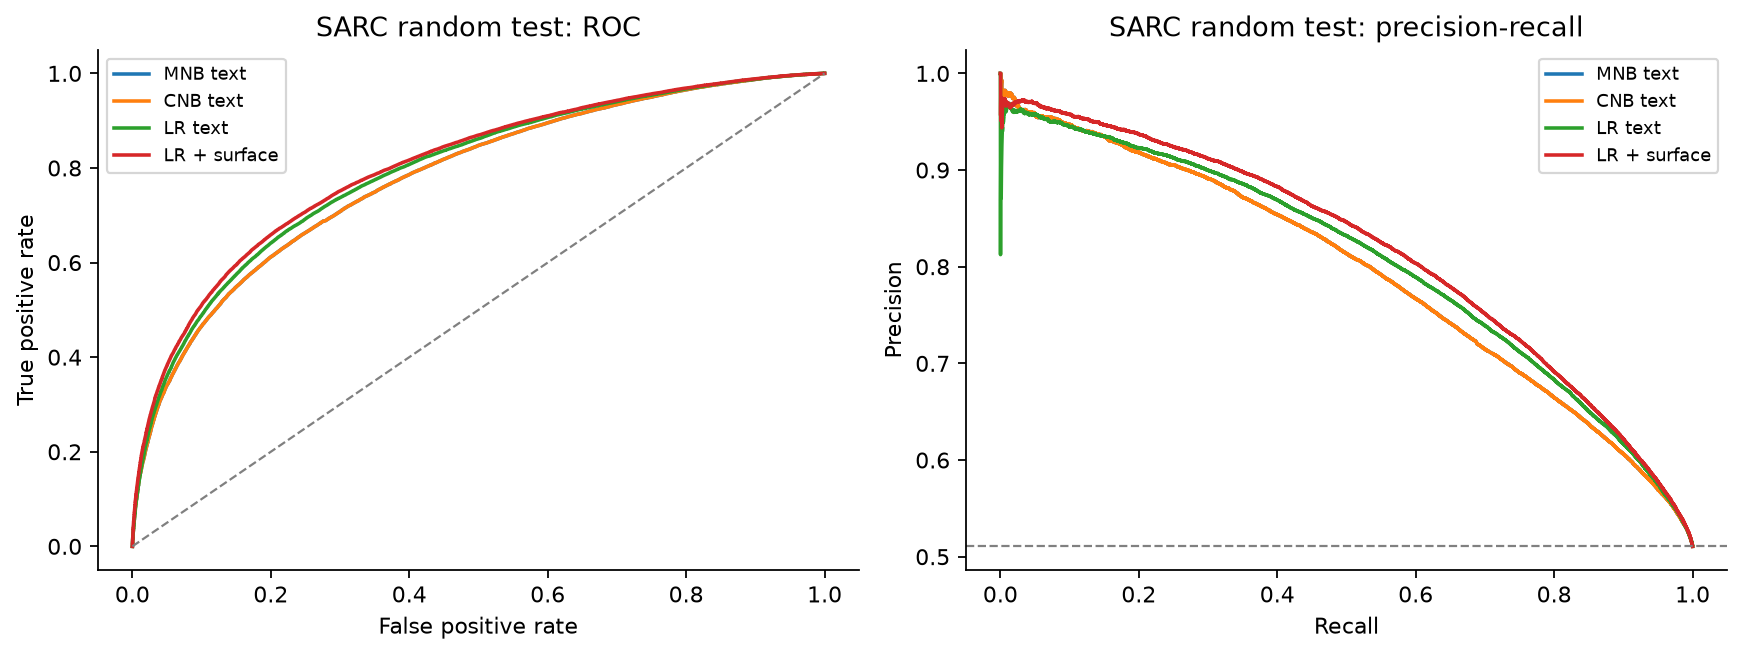

In [21]:
display(Image(filename=str(FIGURES/'P01_roc_pr.png')))

,model,reply_tfidf,reply_tfidf_surface,surface_auc_delta
0,CNB,0.779766,0.740552,-0.039214
1,LR,0.794062,0.802881,0.008819
2,MNB,0.779766,0.740552,-0.039214


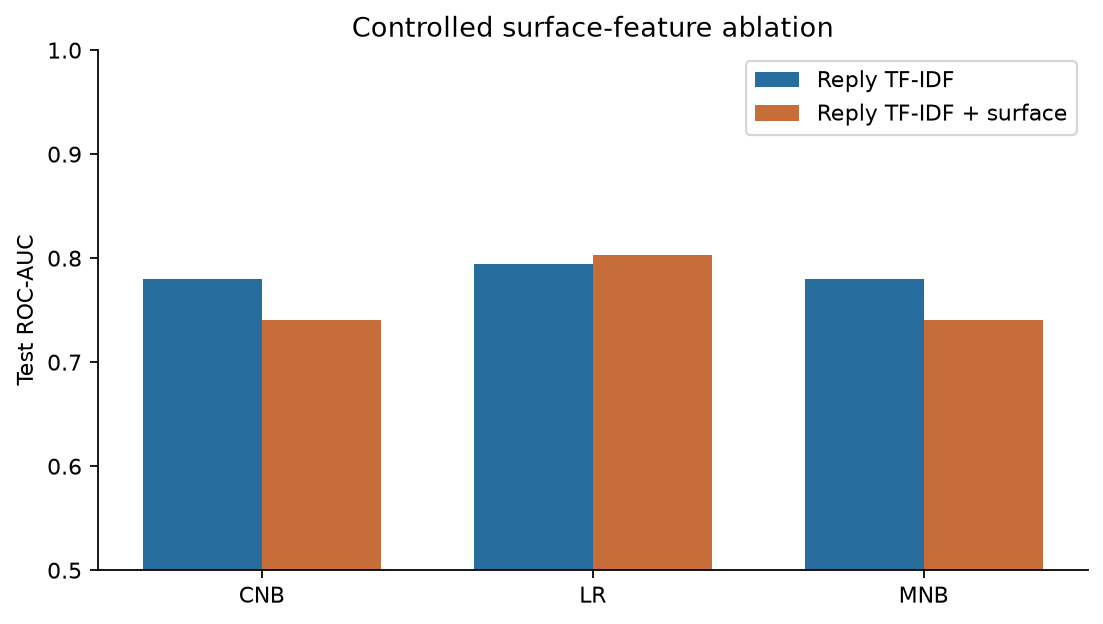

In [22]:
display(pd.read_csv(RESULTS/'surface_ablation.csv'))
display(Image(filename=str(FIGURES/'P03_surface_ablation.png')))

## 4. Operating point and calibration
A 0.75 precision target on validation controls the source operating point; it
is not a calibrated confidence claim. NB/CNB outputs can be overconfident.
Brier scores are provided as a calibration-sensitive diagnostic. Any further
probability calibration for voting must use training/validation data only.

,model,representation,threshold_policy,threshold,precision,recall,f1,brier_score
2,MNB,reply_tfidf,default_0.50,0.500000,0.713259,0.703457,0.708324,0.192511
3,MNB,reply_tfidf,source_validation_precision_0.75,0.546457,0.754121,0.625500,0.683815,0.192511
6,MNB,reply_tfidf_surface,default_0.50,0.500000,0.730416,0.603814,0.661109,0.221899
7,MNB,reply_tfidf_surface,source_validation_precision_0.75,0.600379,0.754694,0.520771,0.616282,0.221899
10,CNB,reply_tfidf,default_0.50,0.500000,0.720368,0.688414,0.704029,0.192416
11,CNB,reply_tfidf,source_validation_precision_0.75,0.537451,0.754121,0.625500,0.683815,0.192416
14,CNB,reply_tfidf_surface,default_0.50,0.500000,0.733312,0.595743,0.657408,0.222507
15,CNB,reply_tfidf_surface,source_validation_precision_0.75,0.591643,0.754694,0.520771,0.616282,0.222507
18,LR,reply_tfidf,default_0.50,0.500000,0.739519,0.699057,0.718719,0.184908
19,LR,reply_tfidf,source_validation_precision_0.75,0.522422,0.754740,0.671557,0.710723,0.184908


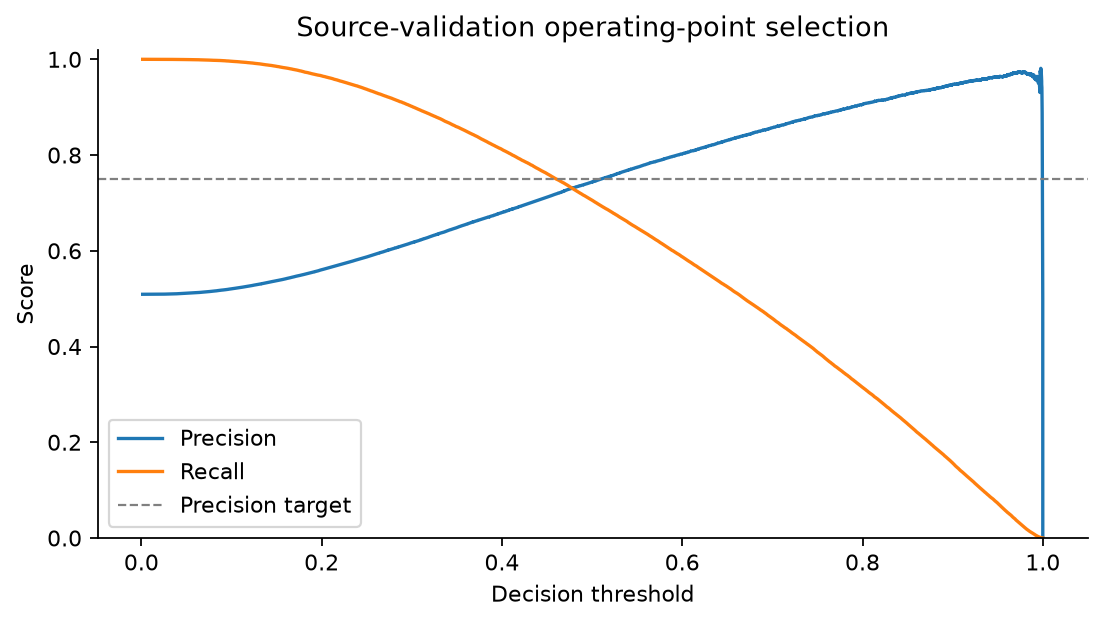

In [23]:
display(metrics[(metrics.dataset=='sarc_random') & (metrics['split']=='test')][
    ['model','representation','threshold_policy','threshold','precision','recall','f1','brier_score']])
display(Image(filename=str(FIGURES/'P06_threshold.png')))

## 5. Generalization
Stress rows below are independent fresh fits; transfer rows are predictions
from the unchanged sarc_random model. AUC changes under stress are descriptive
population shifts, not a causal estimate of community/year dependence.

,dataset,model,representation,roc_auc,auc_delta_vs_random
0,sarc_random,MNB,reply_tfidf,0.779766,0.000000
1,sarc_random,MNB,reply_tfidf_surface,0.740552,0.000000
2,sarc_random,CNB,reply_tfidf,0.779766,0.000000
3,sarc_random,CNB,reply_tfidf_surface,0.740552,0.000000
4,sarc_random,LR,reply_tfidf,0.794062,0.000000
5,sarc_random,LR,reply_tfidf_surface,0.802881,0.000000
6,sarc_temporal,MNB,reply_tfidf,0.763595,-0.016172
7,sarc_temporal,MNB,reply_tfidf_surface,0.718136,-0.022416
8,sarc_temporal,CNB,reply_tfidf,0.763595,-0.016172
9,sarc_temporal,CNB,reply_tfidf_surface,0.718136,-0.022416


,dataset,representation,roc_auc,pr_auc,accuracy,precision,recall,f1
0,figlang_reddit,reply_tfidf,0.756195,0.763097,0.693052,0.705665,0.656357,0.680119
1,figlang_twitter,reply_tfidf,0.668319,0.654623,0.623324,0.641068,0.471166,0.543140
2,tweeteval_irony,reply_tfidf,0.615326,0.514565,0.616667,0.526316,0.354839,0.423892
3,news_headlines,reply_tfidf,0.416790,0.415737,0.465116,0.400470,0.252595,0.309791
4,figlang_reddit,reply_tfidf_surface,0.759319,0.765026,0.697608,0.705036,0.673540,0.688928
5,figlang_twitter,reply_tfidf_surface,0.646573,0.627438,0.607580,0.626786,0.430675,0.510545
6,tweeteval_irony,reply_tfidf_surface,0.584708,0.502999,0.597436,0.491935,0.393548,0.437276
7,news_headlines,reply_tfidf_surface,0.420959,0.417271,0.460183,0.399267,0.269402,0.321724


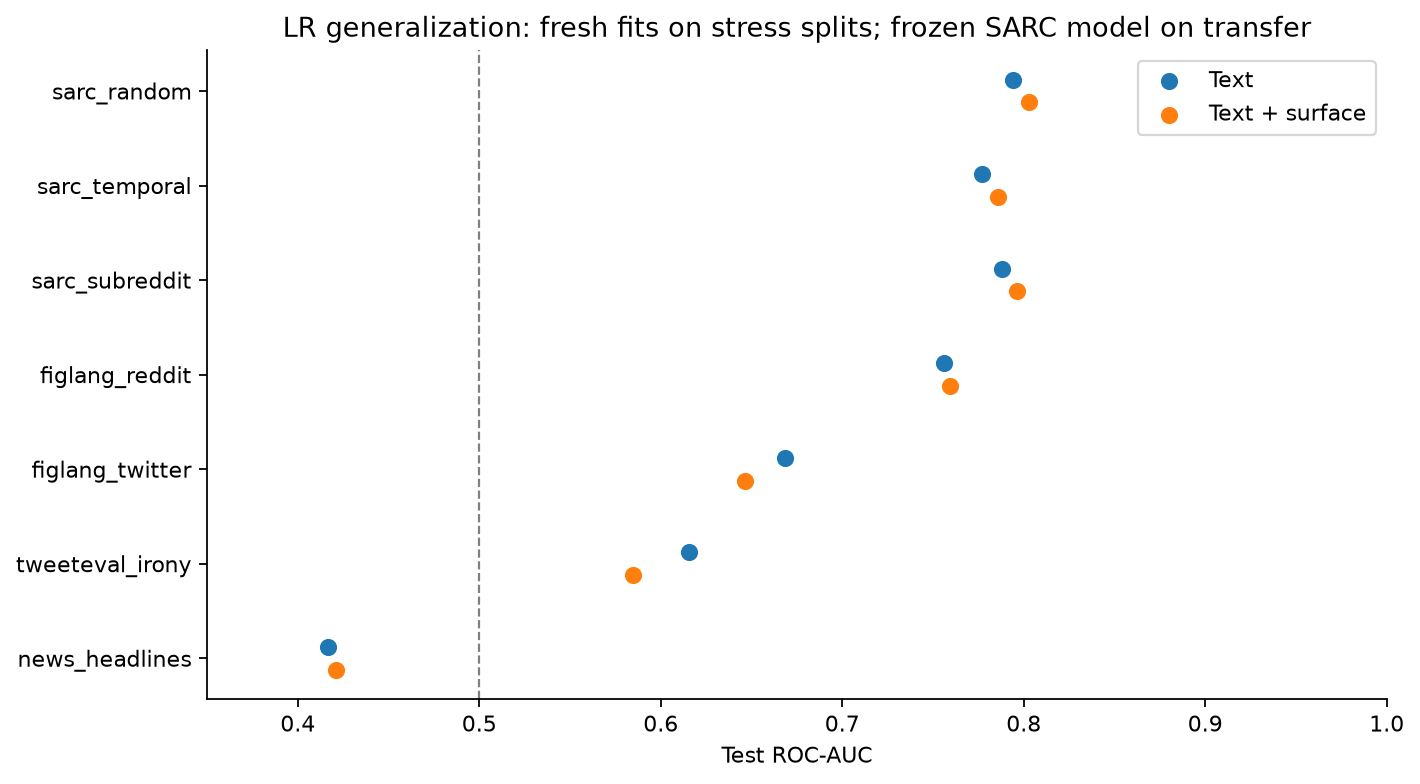

,dataset,prior,accuracy,roc_auc
0,sarc_random,0.509069,0.510707,0.5
1,figlang_reddit,0.509069,0.497153,0.5
2,figlang_twitter,0.509069,0.475219,0.5
3,tweeteval_irony,0.509069,0.397436,0.5
4,news_headlines,0.509069,0.475217,0.5


In [24]:
display(pd.read_csv(RESULTS/'stress_results.csv')[['dataset','model','representation','roc_auc','auc_delta_vs_random']])
display(pd.read_csv(RESULTS/'transfer_results.csv')[['dataset','representation','roc_auc','pr_auc','accuracy','precision','recall','f1']])
display(Image(filename=str(FIGURES/'P04_generalization.png')))
display(pd.read_csv(RESULTS/'dummy_baselines.csv')[['dataset','prior','accuracy','roc_auc']])

## 6. What the models use
Positive LR coefficients push toward sarcasm; negative coefficients push toward
sincerity. An individual example's contribution is TF-IDF × coefficient.
MNB uses class log-probability differences. CNB's complement-derived score
weights are not ordinary class-conditional log probabilities.

Compare the prespecified EDA words with fitted LR weights. Topical terms may
capture political communities rather than general linguistic sarcasm cues.
Correlated features and platform conventions limit causal interpretations.

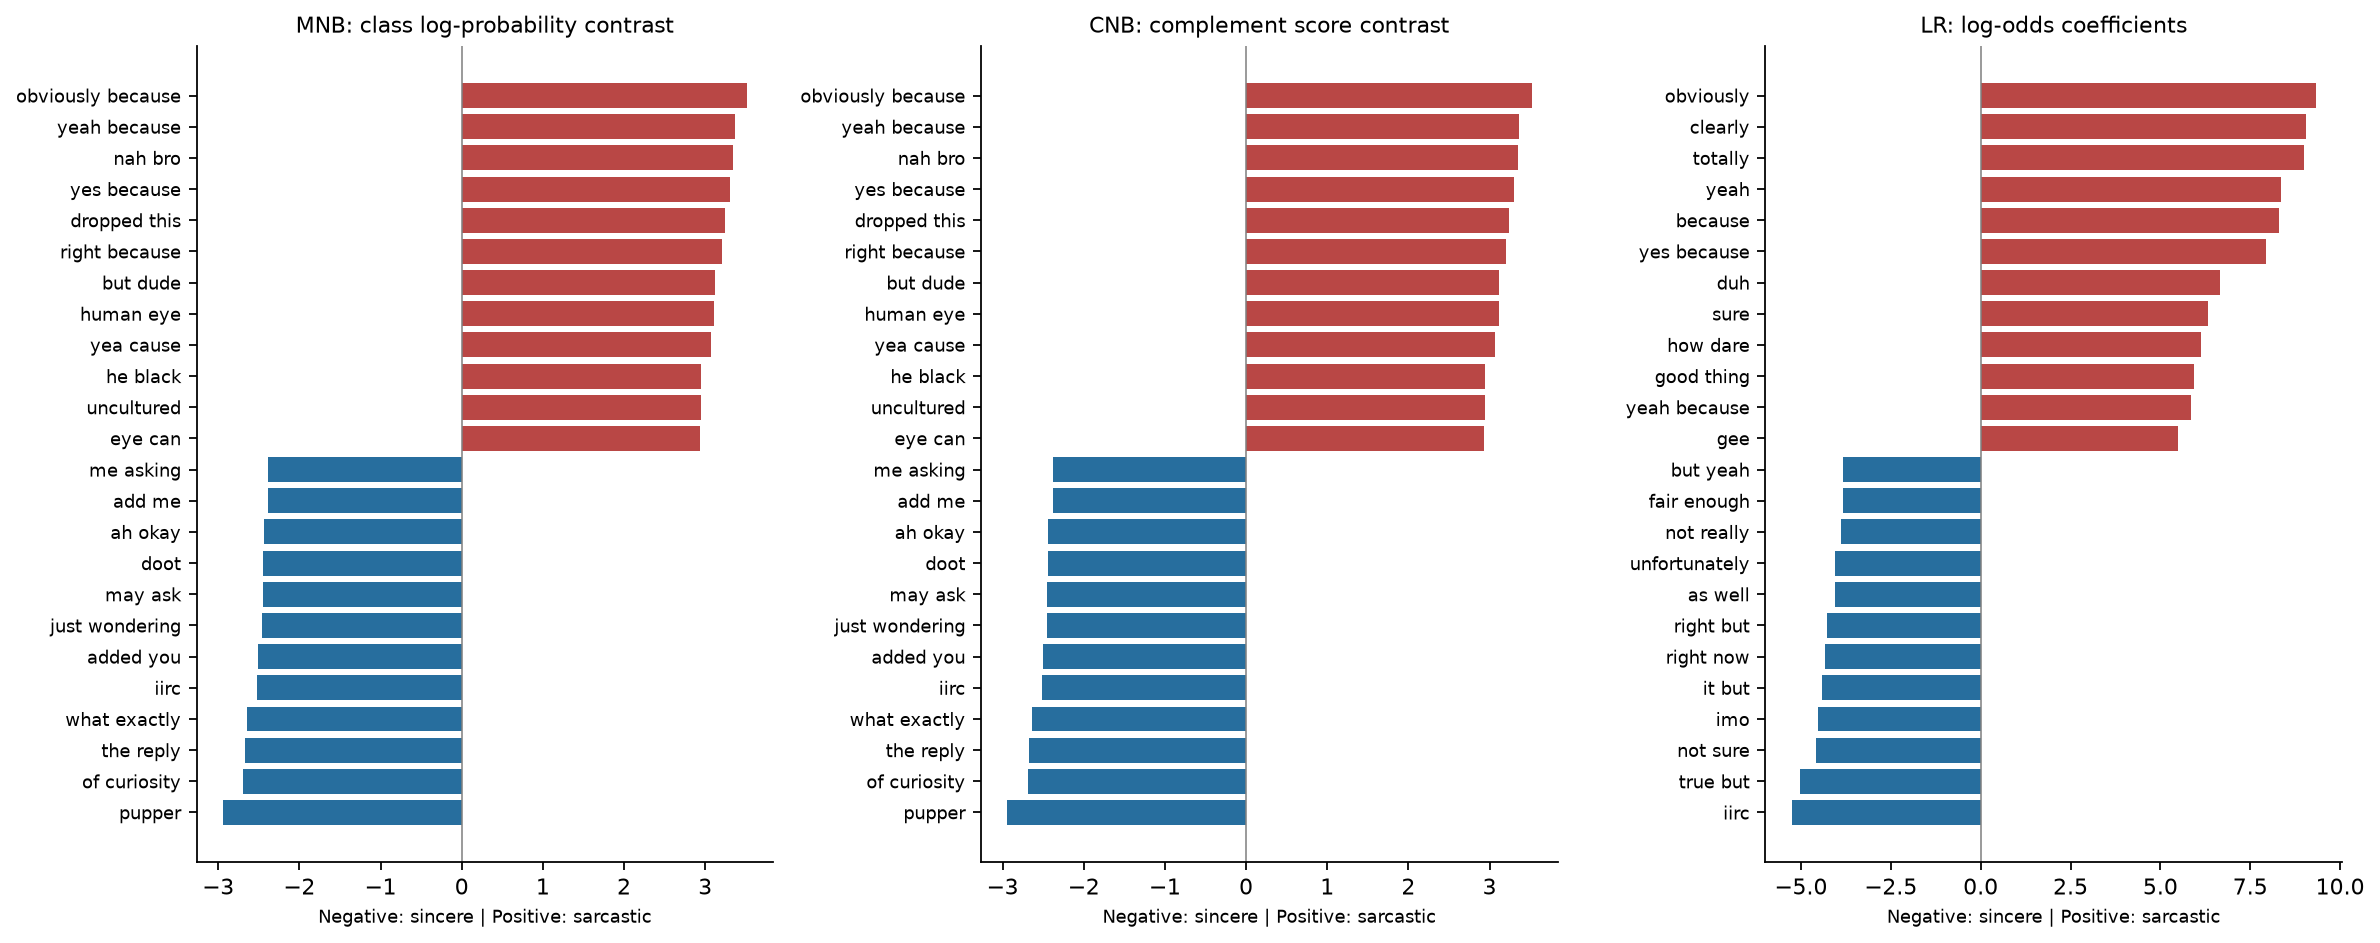

,feature,weight,weight_kind,interpretation
0,yeah,8.366851,log_odds_coefficient,compare direction with supplied EDA
1,because,8.308352,log_odds_coefficient,compare direction with supplied EDA
2,obviously,9.326419,log_odds_coefficient,compare direction with supplied EDA
3,all,2.259903,log_odds_coefficient,compare direction with supplied EDA
4,totally,8.982713,log_odds_coefficient,compare direction with supplied EDA
5,yes,3.010310,log_odds_coefficient,compare direction with supplied EDA
6,clearly,9.060768,log_odds_coefficient,compare direction with supplied EDA
7,we,2.107875,log_odds_coefficient,compare direction with supplied EDA
8,right,3.982374,log_odds_coefficient,compare direction with supplied EDA
9,oh,1.437300,log_odds_coefficient,compare direction with supplied EDA


In [25]:
display(Image(filename=str(FIGURES/'P02_token_weights.png')))
display(pd.read_csv(RESULTS/'eda_token_comparison.csv'))

### Permutation and block importance
Evaluate on a fixed 20,000-row source-validation sample after selection.
Shuffle text and surface blocks, then individual surface quantities, five times.
Word-count bins are shuffled together to preserve a valid bin assignment.
Error bars are shuffle standard deviations, not confidence intervals.

,feature,auc_drop_mean,auc_drop_std,repeats,rows,dataset,split
0,block:text,0.234814,0.003684,5,20000,sarc_random,val
1,block:surface,0.057473,0.002508,5,20000,sarc_random,val
2,surface:n_interjections,0.015556,0.001140,5,20000,sarc_random,val
3,surface:n_ellipsis,0.013961,0.000872,5,20000,sarc_random,val
4,surface:n_exclam,0.013831,0.000409,5,20000,sarc_random,val
5,surface:n_repeat_punct,0.009579,0.000714,5,20000,sarc_random,val
6,surface:word_count_bins,0.009308,0.000717,5,20000,sarc_random,val
7,surface:starts_with_interjection,0.004782,0.000802,5,20000,sarc_random,val
8,surface:n_sentences,0.001198,0.000268,5,20000,sarc_random,val
9,surface:avg_word_len,0.000826,0.000207,5,20000,sarc_random,val


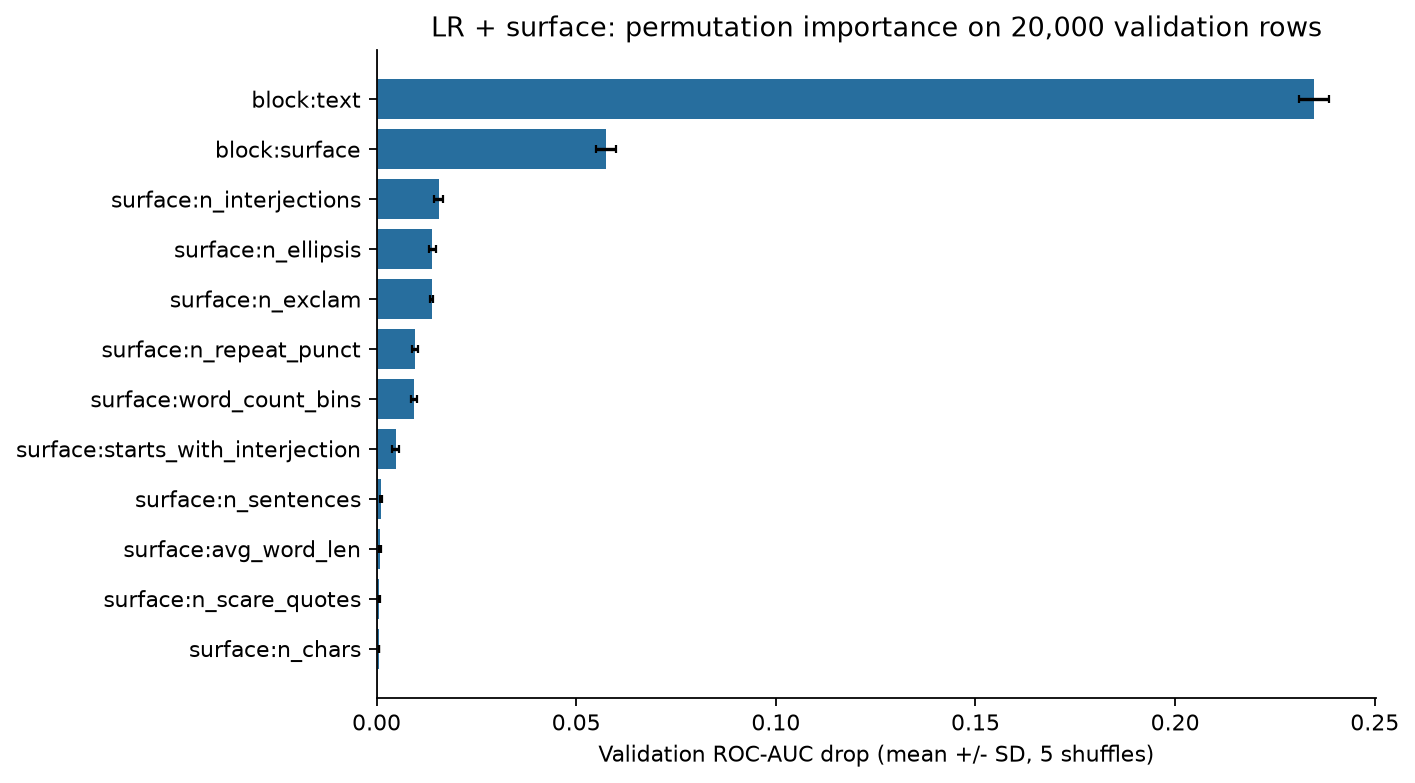

In [26]:
display(pd.read_csv(RESULTS/'lr_permutation_importance.csv'))
display(Image(filename=str(FIGURES/'P05_permutation.png')))

### Confident errors
These are actual held-out mistakes, selected for interpretation after all model
choices were frozen. The JSON file also records each example's largest signed
logit contributions; the predictions should not be used to claim that the noisy
self-annotated labels perfectly capture human intent.

In [27]:
examples = json.loads((RESULTS/'lr_error_examples.json').read_text())
display(pd.DataFrame(examples)[['type','label','probability','comment']])
display(pd.DataFrame(examples[0]['largest_logit_contributions']))

,type,label,probability,comment
0,false_positive,0,0.998453,OHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH...
1,false_positive,0,0.998015,Yes because voter fraud
2,false_positive,0,0.997202,"Yes, because that makes sense."
3,false_negative,1,0.002513,"Thirteenth, iirc"
4,false_negative,1,0.004967,Lol wagie
5,false_negative,1,0.007047,afaik tl;dr iirc


,feature,contribution
0,surface:avg_word_len,7.548952
1,surface:n_sentences,-0.622574
2,surface:n_chars,-0.461677
3,surface:words_0_3,-0.433584
4,surface:n_elongation,0.306903
5,surface:n_allcaps_words,0.109389
6,surface:allcaps_ratio,-0.059737


## 7. Saved model and Person 6 handoff
The fitted bundle contains the vectorizer, optional surface transformer, model,
threshold, parameters and training-scheme metadata. Save/reload checks passed
for every final fit. Inputs are cleaned dataframes produced by the shared pipeline.

Predictions include a BLAKE2b-128 hash of cleaned text as `row_id`, split row
position, label and probability. Join by `row_id`; confirm the labels match.
Use validation predictions for voting weights and held-out test only at the end.

For stacking, generate grouped out-of-fold predictions with the optional switch
below. Vocabulary, IDF, scaling and model are fitted inside each fold. Predictions
on the same examples used to fit the base model are not valid OOF inputs.

In [28]:
import joblib
path = ROOT/'artifacts/person1/best_lr_pipeline.joblib'
if path.exists() and (ROOT/'data/splits/primary/sarc_random/test.parquet').exists():
    bundle = joblib.load(path)
    sample = load_frame('sarc_random','test').iloc[:5]
    display(pd.DataFrame({'comment':sample.comment_clean,'probability':predict(bundle,sample)}))
else:
    print('Download/extract the fitted model artifacts and rebuild data to run this optional prediction demo.')
if RUN_OOF:
    oof = make_oof()
    display(oof.head())
else:
    print('OOF generation not requested in this notebook execution.')

,comment,probability
0,I could use one of those tools.,0.382977
1,because it's what really bothers him... and it...,0.467367
2,At this point they're so stable I could build ...,0.300995
3,Conservatism as an ideology is for sure a reac...,0.167400
4,At first I thought it was instructions on fixi...,0.082605


OOF generation not requested in this notebook execution.


## 8. Interpretation limits
- Lexical models recognize distributional cues; they do not understand context
  or world knowledge. Transfer shifts style, priors and annotation conventions.
- The shared cleaning removed conflicting-label duplicates before splitting;
  the supplied EDA informed feature choices. Results are conditional on that
  curation, not a pristine new benchmark.
- Parent/text overlap is audited, but authors still overlap across splits;
  author IDs are excluded as predictors.
- MNB/CNB probabilities should not be assumed calibrated. Coefficients show
  learned associations, not causal or universal sarcasm markers.
- These are modest-search, single-seed estimates. Small score differences are
  not evidence of statistical significance.

See `docs/person1_report.md` for the complete English report and exact protocols.